# 지역 단위 정책 패키지 연결

## 분석 목적과 범위

`docs/note/260726_교차해석_지역점수_정책패키지_연결안.md` 6절에서 남긴
작업을 실행한다. 실행준비안 포트폴리오 후보지역(즉시실행형 3개,
기반보강형 18개)에 지역별 주력 기여도 군집을 결합해, 우리동네
초대쿠폰·고향방문 로컬페이백·고향생활권 체류패스 세 정책의
**적용 순서·강도**, **상품 콘텐츠**, **채널·타겟 메모**를 지역 단위로
한 번에 생성한다.

- 분석 단위: 인구감소지역 중 CASE 2 N≥30 지원 검토 후보 시군구
  (`population_decline_portfolio_candidates.csv` 21개 행)
- 결합 대상: 클러스터별 지역점수 결과표의 `주력군집`
  (`regional_affinity_cluster_scores.csv`)
- 정책 매핑 근거: 연결안 문서 2절(포트폴리오→적용 순서), 3절(주력
  군집→상품 콘텐츠), 4절(교차해석 공통 변수→채널·타겟)을 그대로
  코드화한다. 새로운 통계 분석은 하지 않는다.
- 이 노트북은 두 결과표를 결합하고 정책 문서의 매핑 규칙을 적용하는
  작업만 수행하며, 원본 점수·군집 계산 로직은 다시 계산하지 않는다.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    """현재 위치에서 프로젝트 루트를 찾는다.

    Args:
        start: 탐색을 시작할 경로.

    Returns:
        `src`와 `data` 디렉터리를 가진 프로젝트 루트.

    Raises:
        FileNotFoundError: 프로젝트 루트를 찾지 못한 경우.
    """
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.path import OUTPUTS_DIR, create_output_directories  # noqa: E402
from src.visualization import COLORS, apply_plot_style  # noqa: E402

NOTEBOOK_FILENAME = "260726_지역단위_정책패키지_연결.ipynb"
REGION_KEYS = ["시도명", "시군구명"]
PORTFOLIO_ORDER = ["즉시실행형", "기반보강형", "공급활용형", "관찰형"]
CLUSTER_ORDER = ["당일 C1", "당일 C2", "숙박 C1", "숙박 C2", "숙박 C3"]

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
warnings.filterwarnings("ignore", category=FutureWarning)

FIGURES_DIR, TABLES_DIR = create_output_directories(NOTEBOOK_FILENAME)
print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"그림 저장 경로: {FIGURES_DIR}")
print(f"표 저장 경로: {TABLES_DIR}")

프로젝트 루트: C:\Users\ilove\OneDrive\Desktop\tourism_poster
그림 저장 경로: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_지역단위_정책패키지_연결_260726_1858\figures
표 저장 경로: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_지역단위_정책패키지_연결_260726_1858\tables


## 데이터 로드

지역점수 노트북(`06_Score/260726_연고관광_클러스터별_지역점수`)의
포트폴리오 후보표와, 이전 산식 검산용 지역별 군집 점수표를
각 결과표의 가장 최근 실행 결과에서 읽는다.

In [2]:
def latest_output_table(notebook_stem: str, table_name: str) -> Path:
    """주어진 노트북의 가장 최근 실행 결과표 경로를 찾는다.

    Args:
        notebook_stem: 확장자를 제외한 노트북 파일명.
        table_name: `tables/` 아래 결과표 파일명.

    Returns:
        수정 시각이 가장 최근인 결과표 경로.

    Raises:
        FileNotFoundError: 조건에 맞는 결과표가 없는 경우.
    """
    candidates = sorted(
        OUTPUTS_DIR.glob(f"{notebook_stem}_*/tables/{table_name}"),
        key=lambda path: path.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(
            f"{notebook_stem}의 {table_name} 결과표를 찾지 못했습니다."
        )
    return candidates[-1]


PORTFOLIO_PATH = latest_output_table(
    "260726_연고관광_클러스터별_지역점수",
    "population_decline_portfolio_candidates.csv",
)
CLUSTER_SCORE_PATH = latest_output_table(
    "260726_연고관광_클러스터별_지역점수",
    "regional_affinity_cluster_scores.csv",
)

portfolio_raw = pd.read_csv(PORTFOLIO_PATH)
cluster_score_raw = pd.read_csv(CLUSTER_SCORE_PATH)

input_paths = pd.Series(
    {
        "포트폴리오 후보표": PORTFOLIO_PATH,
        "군집별 지역점수표": CLUSTER_SCORE_PATH,
    },
    name="입력 경로",
)
display(input_paths.to_frame())
display(
    pd.Series(
        {
            "포트폴리오 후보표 행 수": len(portfolio_raw),
            "군집별 지역점수표 행 수": len(cluster_score_raw),
        },
        name="관측값",
    ).to_frame()
)

,입력 경로
포트폴리오 후보표,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
군집별 지역점수표,C:\Users\ilove\OneDrive\Desktop\tourism_poster...


,관측값
포트폴리오 후보표 행 수,21
군집별 지역점수표 행 수,229


## 데이터 품질과 분석 단위 확인

포트폴리오 후보표의 21개 지역이 모두 군집별 지역점수표의 `시도명 +
시군구명` 복합키와 1:1로 결합되는지, 포트폴리오 유형 구성이 연결안
문서 5절(즉시실행형 3개, 기반보강형 18개)과 일치하는지 확인한다.

In [3]:
portfolio_type_counts = portfolio_raw["포트폴리오유형"].value_counts()
display(portfolio_type_counts.to_frame(name="지역 수"))
if portfolio_type_counts.get("즉시실행형", 0) != 3:
    raise ValueError("즉시실행형 지역 수가 연결안 문서 5절과 다릅니다.")
if portfolio_type_counts.get("기반보강형", 0) != 18:
    raise ValueError("기반보강형 지역 수가 연결안 문서 5절과 다릅니다.")

if portfolio_raw.duplicated(REGION_KEYS).any():
    raise ValueError("포트폴리오 후보표의 지역 복합키가 유일하지 않습니다.")
if cluster_score_raw.duplicated(REGION_KEYS).any():
    raise ValueError("군집별 지역점수표의 지역 복합키가 유일하지 않습니다.")

unmatched = (
    portfolio_raw[REGION_KEYS]
    .merge(
        cluster_score_raw[REGION_KEYS],
        on=REGION_KEYS,
        how="left",
        indicator=True,
    )
    .loc[lambda frame: frame["_merge"].eq("left_only"), REGION_KEYS]
)
if not unmatched.empty:
    raise ValueError(f"군집별 지역점수표와 매칭되지 않은 지역이 있습니다: {unmatched}")
print("포트폴리오 후보 21개 지역이 군집별 지역점수표와 모두 1:1로 매칭됩니다.")

,지역 수
포트폴리오유형,
기반보강형,18
즉시실행형,3


포트폴리오 후보 21개 지역이 군집별 지역점수표와 모두 1:1로 매칭됩니다.


## 전처리 — 두 결과표 결합

포트폴리오 후보표에 군집별 지역점수표의 `주력군집`과 다섯 군집
기여도(`기여도_*`)를 결합한다.

In [4]:
CONTRIBUTION_COLUMNS = [f"기여도_{cluster}" for cluster in CLUSTER_ORDER]

combined = portfolio_raw.merge(
    cluster_score_raw[REGION_KEYS + ["주력군집"] + CONTRIBUTION_COLUMNS],
    on=REGION_KEYS,
    how="left",
    validate="one_to_one",
)
if combined["주력군집"].isna().any():
    raise ValueError("결합 뒤 주력군집이 없는 지역이 있습니다.")

combined["포트폴리오유형"] = pd.Categorical(
    combined["포트폴리오유형"],
    categories=PORTFOLIO_ORDER,
    ordered=True,
)
display(
    combined[
        REGION_KEYS + ["포트폴리오유형", "실행준비안", "주력군집"]
    ].sort_values(["포트폴리오유형", "실행준비안"], ascending=[True, False])
)

,시도명,시군구명,포트폴리오유형,실행준비안,주력군집
0,경상북도,문경시,즉시실행형,56.03,숙박 C3
1,경상남도,밀양시,즉시실행형,55.18,숙박 C3
2,전라북도,남원시,즉시실행형,52.20,숙박 C3
3,충청남도,금산군,기반보강형,55.35,당일 C2
4,충청북도,옥천군,기반보강형,54.99,당일 C2
5,충청남도,예산군,기반보강형,54.00,당일 C2
6,충청북도,영동군,기반보강형,53.04,숙박 C3
7,경상북도,상주시,기반보강형,51.92,숙박 C3
8,충청남도,공주시,기반보강형,51.09,당일 C2
9,충청남도,서천군,기반보강형,50.70,숙박 C3


## 분석 — 정책 매핑 규칙 적용

연결안 문서의 세 매핑을 딕셔너리로 그대로 코드화한다. 4절의 채널·타겟
메모는 문서가 실제로 근거(SHAP·lift)를 제시한 군집에만 채우고,
나머지 군집은 근거 없음으로 명시해 없는 근거를 만들어 채우지 않는다.

In [5]:
# 연결안 문서 2절: 포트폴리오 유형 -> 세 정책의 적용 순서·강도
PORTFOLIO_POLICY_SEQUENCE = {
    "즉시실행형": (
        "세 정책을 원래 설계대로 전 단계 운영. 초대쿠폰→로컬페이백→"
        "체류패스를 한 시즌 내 순차 투입"
    ),
    "기반보강형": (
        "로컬페이백을 바로 전면 도입하지 않는다. 인프라 요구가 낮은 "
        "초대쿠폰과 소규모 체류패스 코스 시범부터 시작하고, 가맹점 "
        "기반이 갖춰진 뒤 로컬페이백을 붙인다"
    ),
    "공급활용형": (
        "로컬페이백·체류패스보다 초대쿠폰(방문 유입)에 예산을 집중해 "
        "기존 공급을 발견시키는 데 집중한다"
    ),
    "관찰형": "초대쿠폰의 소액·단일 버전만 시범 운영해 수요를 먼저 검증한다",
}

# 연결안 문서 3절: 주력 군집 -> 세 정책 각각의 상품 콘텐츠
CLUSTER_POLICY_CONTENT = {
    "당일 C1": {
        "초대쿠폰_상품콘텐츠": "가족·미성년자 동반 초대 쿠폰, 체험시설 공동 혜택",
        "로컬페이백_상품콘텐츠": "활동비 비중이 높은 군집이므로 체험·활동 지출에 페이백 비중 확대",
        "체류패스_상품콘텐츠": "자연·체험 결합 코스(온천·테마·체험) 2~4시간형",
    },
    "당일 C2": {
        "초대쿠폰_상품콘텐츠": "특정 틈새 상품보다 일반 초대 링크·기본 할인",
        "로컬페이백_상품콘텐츠": "예약 없이 즉시 쓸 수 있는 식음·상점 쿠폰(저관여 진입장벽 최소화)",
        "체류패스_상품콘텐츠": "가족·친지집 반경의 반나절 생활상권 코스",
    },
    "숙박 C1": {
        "초대쿠폰_상품콘텐츠": "5인 이상 단체·친척 모임용 공동 초대·공동구매 혜택",
        "로컬페이백_상품콘텐츠": "여행상품·항공 등 고관여 지출 항목에 결제 규모 큰 환급 설계",
        "체류패스_상품콘텐츠": "다인실·단체 동선을 고려한 체험+식음 묶음 코스",
    },
    "숙박 C2": {
        "초대쿠폰_상품콘텐츠": "지역민 추천보다 역·터미널 현장 채널 중심 초대",
        "로컬페이백_상품콘텐츠": "의류·주점 등 1인 생활소비 항목의 소액·즉시 환급",
        "체류패스_상품콘텐츠": "철도역·터미널 연계 1인용 소규모 코스, 환승 단순화",
    },
    "숙박 C3": {
        "초대쿠폰_상품콘텐츠": "3~4인 동행 단위 초대·추천 혜택",
        "로컬페이백_상품콘텐츠": "음식관광 지출에 소폭 가중한 표준형 환급",
        "체류패스_상품콘텐츠": "대표 음식+자연·문화 자원의 1박 2일 표준 코스",
    },
}

# 연결안 문서 4절: 교차해석 공통 변수 근거가 있는 군집만 채운다.
# 나머지 군집(숙박 C1·숙박 C3)은 4절이 다루지 않아 근거 없음으로 둔다.
CLUSTER_CHANNEL_NOTE = {
    "당일 C1": (
        "온라인 정보 이용 lift 1.76 → 초대쿠폰 SNS·온라인 링크 공유 우선. "
        "`정보 없이 방문` 비율은 4.2절 대상이 아니므로 별도 언급 없음"
    ),
    "당일 C2": (
        "`정보 없이 방문` 비율 lift 1.06으로 층 평균과 비슷 → 초대쿠폰의 "
        "사전 공유형 설계가 상대적으로 잘 맞음"
    ),
    "숙박 C1": "교차해석 4절이 다루는 군집이 아니어서 채널 근거 없음",
    "숙박 C2": (
        "온라인 정보 이용 lift 0.36(낮음), 주변인 추천 lift 0.67(과소대표), "
        "20대 비중 lift 2.43 → 초대쿠폰·로컬페이백 홍보를 온라인·지역민 "
        "추천에 의존하지 말고 역·터미널 현장 채널을 1차 채널로 삼는다. "
        "체류패스·로컬페이백은 청년 타겟 문구를 오프라인·현장 채널과 "
        "결합해 설계한다"
    ),
    "숙박 C3": "교차해석 4절이 다루는 군집이 아니어서 채널 근거 없음",
}

policy_content = combined["주력군집"].map(CLUSTER_POLICY_CONTENT).apply(pd.Series)
combined["정책적용순서_강도"] = combined["포트폴리오유형"].map(
    PORTFOLIO_POLICY_SEQUENCE
)
combined["채널_타겟_메모"] = combined["주력군집"].map(CLUSTER_CHANNEL_NOTE)

region_policy_package = pd.concat(
    [
        combined[
            REGION_KEYS
            + [
                "지역명",
                "포트폴리오유형",
                "POT",
                "SUP",
                "실행준비안",
                "주력군집",
                "정책적용순서_강도",
            ]
        ],
        policy_content,
        combined[["채널_타겟_메모"]],
    ],
    axis=1,
).sort_values(
    ["포트폴리오유형", "실행준비안"],
    ascending=[True, False],
).reset_index(drop=True)

display(
    region_policy_package[
        REGION_KEYS + ["포트폴리오유형", "실행준비안", "주력군집"]
    ]
)

,시도명,시군구명,포트폴리오유형,실행준비안,주력군집
0,경상북도,문경시,즉시실행형,56.03,숙박 C3
1,경상남도,밀양시,즉시실행형,55.18,숙박 C3
2,전라북도,남원시,즉시실행형,52.20,숙박 C3
3,충청남도,금산군,기반보강형,55.35,당일 C2
4,충청북도,옥천군,기반보강형,54.99,당일 C2
5,충청남도,예산군,기반보강형,54.00,당일 C2
6,충청북도,영동군,기반보강형,53.04,숙박 C3
7,경상북도,상주시,기반보강형,51.92,숙박 C3
8,충청남도,공주시,기반보강형,51.09,당일 C2
9,충청남도,서천군,기반보강형,50.70,숙박 C3


## 핵심 결과 확인 — 대표 후보지역 3곳

연결안 문서 5절이 제시한 문경시·금산군·밀양시의 주력군집·정책 매핑이
실제 결합 결과와 일치하는지 확인한다.

In [6]:
highlight_regions = ["문경시", "금산군", "밀양시"]
highlight_table = region_policy_package.loc[
    region_policy_package["시군구명"].isin(highlight_regions)
]
display(
    highlight_table[
        [
            "지역명",
            "포트폴리오유형",
            "실행준비안",
            "주력군집",
            "정책적용순서_강도",
            "채널_타겟_메모",
        ]
    ]
)

,지역명,포트폴리오유형,실행준비안,주력군집,정책적용순서_강도,채널_타겟_메모
0,경상북도 문경시,즉시실행형,56.03,숙박 C3,세 정책을 원래 설계대로 전 단계 운영. 초대쿠폰→로컬페이백→체류패스를 한 시즌 내...,교차해석 4절이 다루는 군집이 아니어서 채널 근거 없음
1,경상남도 밀양시,즉시실행형,55.18,숙박 C3,세 정책을 원래 설계대로 전 단계 운영. 초대쿠폰→로컬페이백→체류패스를 한 시즌 내...,교차해석 4절이 다루는 군집이 아니어서 채널 근거 없음
3,충청남도 금산군,기반보강형,55.35,당일 C2,로컬페이백을 바로 전면 도입하지 않는다. 인프라 요구가 낮은 초대쿠폰과 소규모 체류...,`정보 없이 방문` 비율 lift 1.06으로 층 평균과 비슷 → 초대쿠폰의 사전 ...


## 시각화

포트폴리오 유형별로 정렬한 실행준비안 점수 막대에 주력군집을 직접
레이블로 표시해, 어느 지역이 어떤 순서·콘텐츠 조합으로 묶이는지 한
그림에서 확인한다.

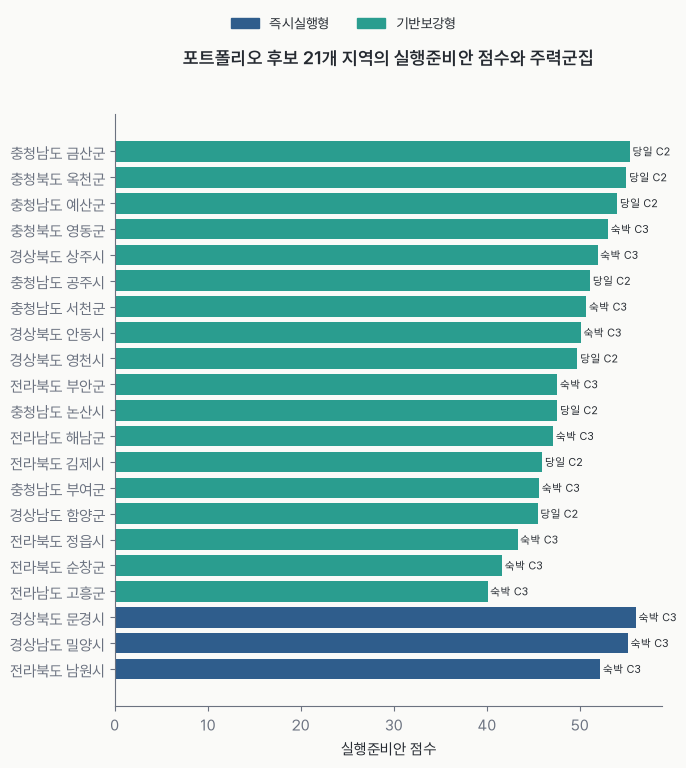

그림 저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_지역단위_정책패키지_연결_260726_1858\figures\region_policy_package_readiness.png


In [7]:
apply_plot_style()

PORTFOLIO_COLORS = {
    "즉시실행형": COLORS["primary"],
    "기반보강형": COLORS["secondary"],
}
plot_data = region_policy_package.sort_values(
    ["포트폴리오유형", "실행준비안"],
    ascending=[True, True],
)
bar_colors = plot_data["포트폴리오유형"].map(PORTFOLIO_COLORS)

fig, ax = plt.subplots(figsize=(7, 8))
bars = ax.barh(
    plot_data["지역명"],
    plot_data["실행준비안"],
    color=bar_colors,
)
for bar, cluster in zip(bars, plot_data["주력군집"]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        cluster,
        va="center",
        fontsize=8,
        color=COLORS["ink"],
    )
ax.set_xlabel("실행준비안 점수")
ax.set_title(
    "포트폴리오 후보 21개 지역의 실행준비안 점수와 주력군집",
    pad=36,
)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color)
    for color in PORTFOLIO_COLORS.values()
]
fig.legend(
    legend_handles,
    PORTFOLIO_COLORS.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2,
    frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))

figure_path = FIGURES_DIR / "region_policy_package_readiness.png"
fig.savefig(figure_path, dpi=900)
plt.show()
print(f"그림 저장: {figure_path}")

## 결과 저장

In [8]:
table_path = TABLES_DIR / "region_policy_package_recommendations.csv"
region_policy_package.to_csv(table_path, index=False, encoding="utf-8-sig")
print(f"표 저장: {table_path}")

표 저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_지역단위_정책패키지_연결_260726_1858\tables\region_policy_package_recommendations.csv


## 핵심 결과와 한계

- 포트폴리오 후보 21개 지역(즉시실행형 3개, 기반보강형 18개) 전체에
  `정책적용순서_강도`(2절), `초대쿠폰/로컬페이백/체류패스_상품콘텐츠`
  (3절), `채널_타겟_메모`(4절)를 결합해
  `region_policy_package_recommendations.csv`로 저장했다.
- 연결안 문서 5절의 대표 후보지역(문경시·금산군·밀양시)이 결합 결과에서
  기대한 포트폴리오 유형·정책 순서와 일치하는지 위에서 확인했다.
- 채널·타겟 메모는 교차해석 문서 4절이 실제로 근거를 제시한 당일
  C1·당일 C2·숙박 C2에만 채웠다. 숙박 C1·숙박 C3이 주력군집인 지역은
  채널 근거가 없다는 점을 그대로 남겼으며, 이 지역에 채널 전략을
  적용하려면 교차해석 분석을 해당 군집으로 확장해야 한다.
- 이 결합은 기존 두 노트북이 이미 계산한 점수·군집 배정을 그대로
  가져와 조합한 것이며, 점수·군집 산출 로직 자체를 다시 검증하지는
  않는다. 원 점수의 타당성은 각 원본 노트북의 한계를 따른다.
- 클러스터 lift·기여도·실행준비안 점수 모두 정책 개입의 인과 효과가
  아니라 탐색적 우선순위 지표이므로, 이 표의 매핑도 설계 우선순위
  근거로만 사용한다.

In [9]:
from src.notebook_sync import sync_script_from_notebook

sync_script_from_notebook(
    "notebooks/07_Cross/260726_지역단위_정책패키지_연결.ipynb"
)

생성 스크립트를 노트북 기준으로 만들었습니다: C:\Users\ilove\OneDrive\Desktop\tourism_poster\script\260726_지역단위_정책패키지_연결.py


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/script/260726_지역단위_정책패키지_연결.py')